<a href="https://colab.research.google.com/github/nguyen23012007/MY_PROJECT/blob/main/BTVNT2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

92.22222222222223
88.01587301587303


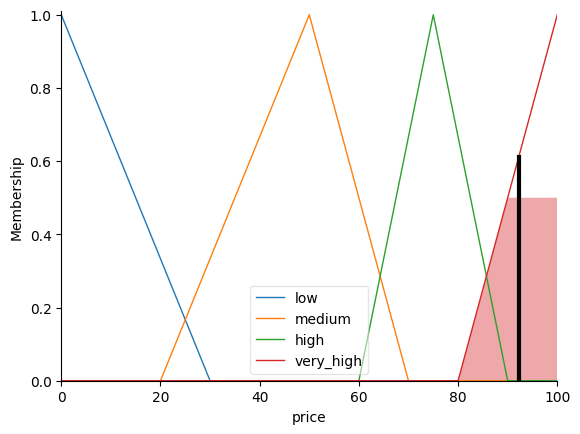

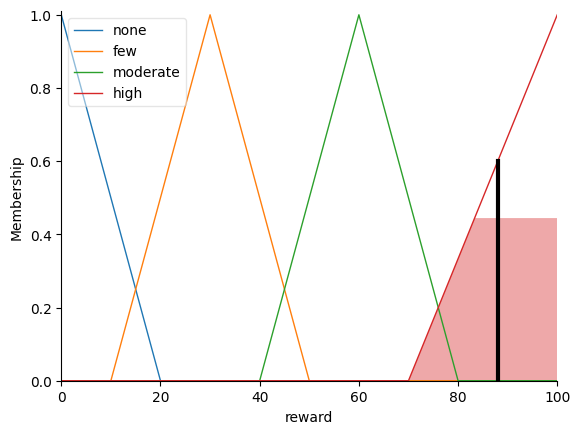

In [19]:
#2.11
!pip install scikit-fuzzy

import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

distance = ctrl.Antecedent(np.arange(0, 51, 1), 'distance')
traffic = ctrl.Antecedent(np.arange(0, 101, 1), 'traffic')
demand = ctrl.Antecedent(np.arange(0, 101, 1), 'demand')
weather = ctrl.Antecedent(np.arange(0, 11, 1), 'weather')
rating = ctrl.Antecedent(np.arange(1, 6, 0.1), 'rating')
punctuality = ctrl.Antecedent(np.arange(0, 101, 1), 'punctuality')

price = ctrl.Consequent(np.arange(0, 101, 1), 'price')
reward = ctrl.Consequent(np.arange(0, 101, 1), 'reward')

distance['short'] = fuzz.trimf(distance.universe, [0, 0, 3])
distance['medium'] = fuzz.trimf(distance.universe, [2, 5, 8])
distance['long'] = fuzz.trimf(distance.universe, [6, 12, 20])
distance['very_long'] = fuzz.trimf(distance.universe, [15, 30, 50])

traffic['low'] = fuzz.trimf(traffic.universe, [0, 0, 30])
traffic['medium'] = fuzz.trimf(traffic.universe, [20, 50, 70])
traffic['high'] = fuzz.trimf(traffic.universe, [60, 100, 100])

demand['low'] = fuzz.trimf(demand.universe, [0, 0, 30])
demand['medium'] = fuzz.trimf(demand.universe, [20, 50, 70])
demand['high'] = fuzz.trimf(demand.universe, [60, 100, 100])

weather['good'] = fuzz.trimf(weather.universe, [0, 0, 3])
weather['moderate'] = fuzz.trimf(weather.universe, [2, 5, 7])
weather['bad'] = fuzz.trimf(weather.universe, [6, 10, 10])

rating['poor'] = fuzz.trimf(rating.universe, [1, 1, 2.5])
rating['average'] = fuzz.trimf(rating.universe, [2.6, 3.5, 4])
rating['good'] = fuzz.trimf(rating.universe, [4.1, 5, 5])

punctuality['late'] = fuzz.trimf(punctuality.universe, [0, 0, 50])
punctuality['ontime'] = fuzz.trimf(punctuality.universe, [40, 60, 80])
punctuality['early'] = fuzz.trimf(punctuality.universe, [70, 100, 100])

price['low'] = fuzz.trimf(price.universe, [0, 0, 30])
price['medium'] = fuzz.trimf(price.universe, [20, 50, 70])
price['high'] = fuzz.trimf(price.universe, [60, 75, 90])
price['very_high'] = fuzz.trimf(price.universe, [80, 100, 100])

reward['none'] = fuzz.trimf(reward.universe, [0, 0, 20])
reward['few'] = fuzz.trimf(reward.universe, [10, 30, 50])
reward['moderate'] = fuzz.trimf(reward.universe, [40, 60, 80])
reward['high'] = fuzz.trimf(reward.universe, [70, 100, 100])

rule1 = ctrl.Rule(distance['short'] & traffic['low'] & demand['low'], price['low'])
rule2 = ctrl.Rule(distance['short'] & traffic['medium'] & demand['high'], price['medium'])
rule3 = ctrl.Rule(distance['medium'] & traffic['high'] & demand['high'], price['high'])
rule4 = ctrl.Rule(distance['long'] & traffic['medium'] & weather['good'], price['medium'])
rule5 = ctrl.Rule(distance['long'] & traffic['high'] & weather['bad'], price['very_high'])
rule6 = ctrl.Rule(distance['very_long'] & traffic['high'] & demand['high'], price['very_high'])
rule7 = ctrl.Rule(distance['medium'] & traffic['low'] & demand['low'], price['medium'])
rule8 = ctrl.Rule(distance['short'] & traffic['high'] & weather['bad'], price['high'])
rule9 = ctrl.Rule(distance['very_long'] & weather['bad'], price['high'])
rule10 = ctrl.Rule(distance['medium'] & traffic['medium'] & weather['moderate'], price['medium'])

rule11 = ctrl.Rule(rating['good'] & punctuality['early'], reward['high'])
rule12 = ctrl.Rule(rating['average'] & punctuality['ontime'], reward['moderate'])
rule13 = ctrl.Rule(rating['poor'] & punctuality['late'], reward['none'])
rule14 = ctrl.Rule(distance['long'] & traffic['high'] & punctuality['ontime'], reward['high'])
rule15 = ctrl.Rule(distance['medium'] & traffic['medium'] & rating['good'], reward['moderate'])
rule16 = ctrl.Rule(distance['very_long'] & weather['bad'] & rating['good'], reward['high'])
rule17 = ctrl.Rule(distance['short'] & rating['average'] & punctuality['ontime'], reward['few'])
rule18 = ctrl.Rule(distance['long'] & traffic['high'] & punctuality['late'], reward['few'])
rule19 = ctrl.Rule(distance['medium'] & weather['moderate'] & rating['good'], reward['moderate'])

rule20 = ctrl.Rule(distance['short'] & weather['good'] & rating['good'], reward['few'])

price_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9, rule10])
reward_ctrl = ctrl.ControlSystem([rule11, rule12, rule13, rule14, rule15, rule16, rule17, rule18, rule19, rule20])

price_sim = ctrl.ControlSystemSimulation(price_ctrl)
reward_sim = ctrl.ControlSystemSimulation(reward_ctrl)

price_sim.input['distance'] = 10
price_sim.input['traffic'] = 80
price_sim.input['demand'] = 75
price_sim.input['weather'] = 8

reward_sim.input['distance'] = 10
reward_sim.input['traffic'] = 80
reward_sim.input['rating'] = 4.5
reward_sim.input['punctuality'] = 85
reward_sim.input['weather'] = 8

price_sim.compute()
reward_sim.compute()

print(price_sim.output['price'])
print(reward_sim.output['reward'])

price.view(sim=price_sim)
reward.view(sim=reward_sim)

/bin/bash: line 1: import: command not found
Recommended Discount: 37.02%


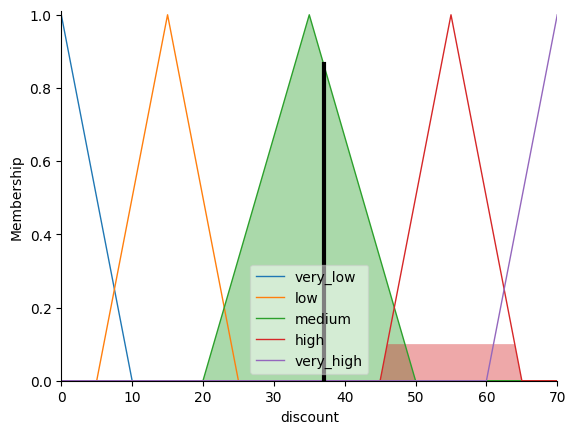

In [39]:
#2.12
!import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

rating = ctrl.Antecedent(np.arange(0, 5.1, 0.1), 'rating')
sales = ctrl.Antecedent(np.arange(0, 101, 1), 'sales')
profit = ctrl.Antecedent(np.arange(0, 101, 1), 'profit')
season = ctrl.Antecedent(np.arange(0, 101, 1), 'season')
competitor = ctrl.Antecedent(np.arange(0, 101, 1), 'competitor')

discount = ctrl.Consequent(np.arange(0, 71, 1), 'discount')

rating.automf(names=['low', 'medium', 'high'])
sales.automf(names=['low', 'medium', 'high'])
profit.automf(names=['low', 'medium', 'high'])
season.automf(names=['none', 'moderate', 'high'])
competitor.automf(names=['low', 'medium', 'high'])

discount['very_low'] = fuzz.trimf(discount.universe, [0, 0, 10])
discount['low'] = fuzz.trimf(discount.universe, [5, 15, 25])
discount['medium'] = fuzz.trimf(discount.universe, [20, 35, 50])
discount['high'] = fuzz.trimf(discount.universe, [45, 55, 65])
discount['very_high'] = fuzz.trimf(discount.universe, [60, 70, 70])

rules = [
    ctrl.Rule(rating['high'] & sales['high'] & profit['high'], discount['very_low']),
    ctrl.Rule(season['high'] & competitor['medium'], discount['medium']),
    ctrl.Rule(season['high'] & competitor['high'], discount['high']),
    ctrl.Rule(sales['low'] & profit['low'], discount['high']),
    ctrl.Rule(season['moderate'] | competitor['medium'], discount['medium']),
    ctrl.Rule(rating['medium'] & sales['medium'], discount['medium']),
    ctrl.Rule(profit['low'] & season['moderate'], discount['medium'])
]

discount_ctrl = ctrl.ControlSystem(rules)
discount_sim = ctrl.ControlSystemSimulation(discount_ctrl)

discount_sim.input['rating'] = 4.3
discount_sim.input['sales'] = 45
discount_sim.input['profit'] = 15
discount_sim.input['season'] = 80
discount_sim.input['competitor'] = 50

discount_sim.compute()

print(f"Recommended Discount: {discount_sim.output['discount']:.2f}%")
discount.view(sim=discount_sim)
plt.show()

Discount (%): 20.0


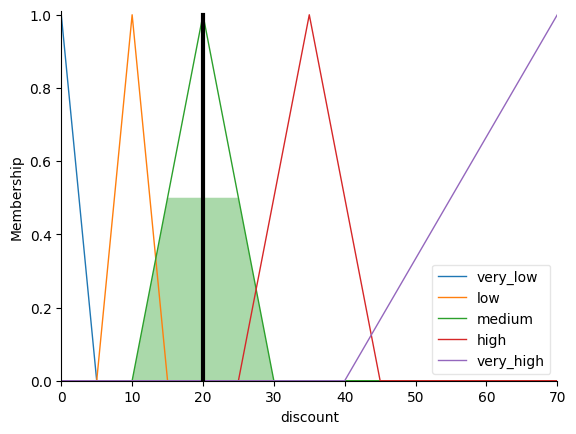

In [15]:
#2.13
!pip install scikit-fuzzy

import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

product_demand = ctrl.Antecedent(np.arange(0, 101, 1), 'product_demand')
competitor_pressure = ctrl.Antecedent(np.arange(0, 101, 1), 'competitor_pressure')
store_reputation = ctrl.Antecedent(np.arange(0, 5.1, 0.1), 'store_reputation')
profit_margin = ctrl.Antecedent(np.arange(0, 101, 1), 'profit_margin')
seasonal_demand = ctrl.Antecedent(np.arange(0, 101, 1), 'seasonal_demand')

discount = ctrl.Consequent(np.arange(0, 71, 1), 'discount')

product_demand['low'] = fuzz.trimf(product_demand.universe, [0, 0, 30])
product_demand['medium'] = fuzz.trimf(product_demand.universe, [20, 50, 70])
product_demand['high'] = fuzz.trimf(product_demand.universe, [60, 100, 100])

competitor_pressure['low'] = fuzz.trimf(competitor_pressure.universe, [0, 0, 30])
competitor_pressure['medium'] = fuzz.trimf(competitor_pressure.universe, [20, 50, 70])
competitor_pressure['high'] = fuzz.trimf(competitor_pressure.universe, [60, 100, 100])

store_reputation['low'] = fuzz.trimf(store_reputation.universe, [0, 0, 4.0])
store_reputation['medium'] = fuzz.trimf(store_reputation.universe, [3.8, 4.2, 4.5])
store_reputation['high'] = fuzz.trimf(store_reputation.universe, [4.4, 5.0, 5.0])

profit_margin['low'] = fuzz.trimf(profit_margin.universe, [0, 0, 30])
profit_margin['medium'] = fuzz.trimf(profit_margin.universe, [20, 50, 70])
profit_margin['high'] = fuzz.trimf(profit_margin.universe, [60, 100, 100])

seasonal_demand['none'] = fuzz.trimf(seasonal_demand.universe, [0, 0, 30])
seasonal_demand['medium'] = fuzz.trimf(seasonal_demand.universe, [20, 50, 70])
seasonal_demand['high'] = fuzz.trimf(seasonal_demand.universe, [60, 100, 100])

discount['very_low'] = fuzz.trimf(discount.universe, [0, 0, 5])
discount['low'] = fuzz.trimf(discount.universe, [5, 10, 15])
discount['medium'] = fuzz.trimf(discount.universe, [10, 20, 30])
discount['high'] = fuzz.trimf(discount.universe, [25, 35, 45])
discount['very_high'] = fuzz.trimf(discount.universe, [40, 70, 70])

rule1 = ctrl.Rule(product_demand['high'] & competitor_pressure['low'] & profit_margin['low'], discount['very_low'])
rule2 = ctrl.Rule(product_demand['low'] & competitor_pressure['high'] & profit_margin['high'], discount['high'])
rule3 = ctrl.Rule(store_reputation['high'] & profit_margin['medium'] & seasonal_demand['high'], discount['medium'])
rule4 = ctrl.Rule(competitor_pressure['high'] & seasonal_demand['high'] & profit_margin['high'], discount['very_high'])
rule5 = ctrl.Rule(store_reputation['low'] & product_demand['medium'] & profit_margin['low'], discount['medium'])
rule6 = ctrl.Rule(product_demand['high'] & seasonal_demand['none'] & competitor_pressure['low'], discount['very_low'])
rule7 = ctrl.Rule(profit_margin['high'] & competitor_pressure['medium'] & seasonal_demand['medium'], discount['medium'])

rule8 = ctrl.Rule(profit_margin['high'] & competitor_pressure['medium'] & seasonal_demand['high'], discount['medium'])

rule9 = ctrl.Rule(product_demand['medium'], discount['medium'])

discount_ctrl = ctrl.ControlSystem([
    rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9
])

discount_sim = ctrl.ControlSystemSimulation(discount_ctrl)

discount_sim.input['product_demand'] = 90
discount_sim.input['competitor_pressure'] = 50
discount_sim.input['store_reputation'] = 4.2
discount_sim.input['profit_margin'] = 80
discount_sim.input['seasonal_demand'] = 90

discount_sim.compute()

print("Discount (%):", discount_sim.output['discount'])

discount.view(sim=discount_sim)

Số đơn nên gom: 8.14
Mức ưu tiên: 5.00


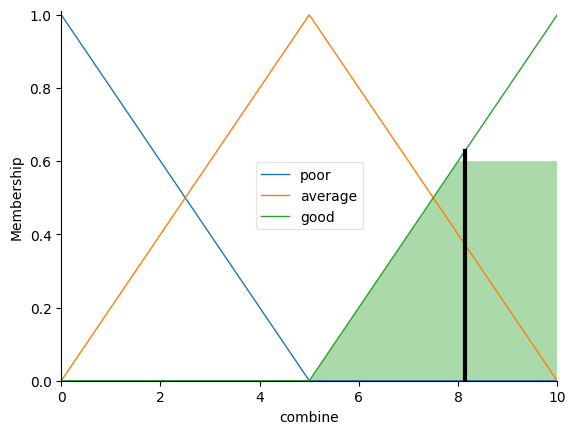

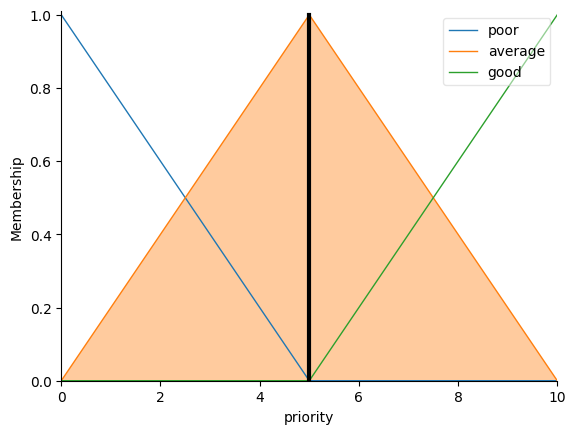

In [40]:
#2.14
import numpy as np
import skfuzzy as fuzzy
from skfuzzy import control as ctrl

do_day_don = ctrl.Antecedent(np.arange(0, 11, 1), 'density')
muc_do_khan_cap = ctrl.Antecedent(np.arange(0, 11, 1), 'urgency')
tai_xe = ctrl.Antecedent(np.arange(0, 11, 1), 'load')
loi_nhuan = ctrl.Antecedent(np.arange(0, 11, 1), 'profit')

so_don_gom = ctrl.Consequent(np.arange(0, 11, 1), 'combine')
muc_uu_tien = ctrl.Consequent(np.arange(0, 11, 1), 'priority')

do_day_don.automf(3)
muc_do_khan_cap.automf(3)
tai_xe.automf(3)
loi_nhuan.automf(3)
so_don_gom.automf(3)
muc_uu_tien.automf(3)

rules = [
    ctrl.Rule(do_day_don['good'] & tai_xe['poor'], so_don_gom['good']),
    ctrl.Rule(tai_xe['good'] | do_day_don['poor'], so_don_gom['poor']),
    ctrl.Rule(muc_do_khan_cap['good'] & loi_nhuan['good'], muc_uu_tien['good']),
    ctrl.Rule(muc_do_khan_cap['poor'], muc_uu_tien['poor']),
    ctrl.Rule(muc_do_khan_cap['average'], muc_uu_tien['average'])
]

he_thong = ctrl.ControlSystem(rules)
mo_phong = ctrl.ControlSystemSimulation(he_thong)

mo_phong.input['density'] = 9
mo_phong.input['urgency'] = 5
mo_phong.input['load'] = 2
mo_phong.input['profit'] = 5

mo_phong.compute()

print(f"Số đơn nên gom: {mo_phong.output.get('combine', 0):.2f}")
print(f"Mức ưu tiên: {mo_phong.output.get('priority', 0):.2f}")

so_don_gom.view(sim=mo_phong)
muc_uu_tien.view(sim=mo_phong)